科目0均值: 85.67551304328401


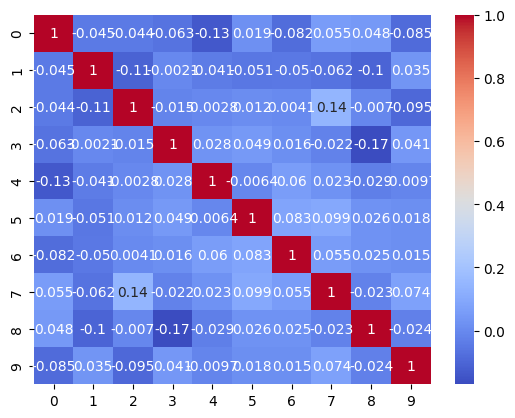

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from util.data_generate import *
from util.methods import *

# 1. 参数设置
p = 100
m = 10
seed = 8
J = 10000
group_sizes=[15, 10, 20, 10, 15, 10, 10, 10]
# 2. 生成均值（70-90分）
mu,std,R,Sigma = data4(p=p, seed=seed, group_sizes=group_sizes)

# 4. 生成数据
X = np.random.multivariate_normal(mu, Sigma, size=1000)
X = np.clip(X, 0, 100)

# 5. 验证
print("科目0均值:", np.mean(X[:, 0])) 
sns.heatmap(np.corrcoef(X[:, 75:85].T), annot=True, cmap="coolwarm")
plt.show()

In [3]:
B,mixed_index = mixed(p,m,mu,std,R,Sigma,J=J) #对协方差矩阵进行cholesky分解
mixed_index

[98, 64, 48, 43, 40, 22, 90, 50, 53, 65]

In [4]:
U, submodular_index = SAA(p,m,mu,std,R,Sigma,J=J)
submodular_index

[98, 64, 30, 43, 22, 48, 53, 40, 24, 90]

In [ ]:
#混合优化结果
J = 100000
G_cul = 0
for j in range(J):
    z = np.random.randn(m)
    temp = mu[mixed_index] + B @ z
    G_cul += np.min(temp)
G1 = G_cul/J
G1

np.float64(44.41097930291387)

In [ ]:
#SAA优化结果
J = 100000
G_cul = 0
for j in range(J):
    z = np.random.randn(m)
    temp = mu[submodular_index] + U @ z
    G_cul += np.min(temp)
G3 = G_cul/J
G3

np.float64(44.39423591390372)